# What are the most demanded skills for the top 5 most popular data roles?

## Methodology
1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings


In [1]:
#Turn off warning notification
import warnings
warnings.filterwarnings("ignore")

import datasets
datasets.logging.set_verbosity_error()


### Import Libraries and Data

In [2]:
# Import library
import pandas as pd
import numpy as np
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

### Filter Data for SEA (Southeast Asia)

In [3]:
countries = ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia' , 'Myanmar'
             , 'Philippines', 'Singapore', 'Thailand', 'East Timor', 'Vietnam']

In [4]:
df_SEA = df[df['job_country'].isin(countries)]

### Explode Skills

Converts the job_skills column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the job_title and job_skills columns, allowing us to analyze the distribution of skills across different data job titles.

In [5]:
df_skills = df_SEA.explode(column=['job_skills'])

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
25,"Senior Officer, Data Analyst, GTO",sql
44,Binance Accelerator Program - Data Scientist (...,python
44,Binance Accelerator Program - Data Scientist (...,java
44,Binance Accelerator Program - Data Scientist (...,scala
47,Senior Data Engineering,sql
...,...,...
785736,DevOps Engineer,kubernetes
785736,DevOps Engineer,docker
785736,DevOps Engineer,ansible
785738,Commercial Analyst - Start Now,powerpoint


### Count Skills per Job Title

Groups DataFrame by job_skills and job_title_short, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, df_skills_count, shows the frequency of each skill with each job title.

In [6]:
#Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name = 'skill_count')

# Sort the values by skill_count in descending order

df_skills_count = df_skills_count.sort_values(
                                                by = 'skill_count'
                                                , ascending = False)

df_skills_count

,job_skills,job_title_short,skill_count
1393,sql,Data Analyst,7397
1394,sql,Data Engineer,6805
1102,python,Data Engineer,6217
398,excel,Data Analyst,6168
1101,python,Data Analyst,5370
...,...,...,...
787,microsoft teams,Cloud Engineer,1
851,neo4j,Cloud Engineer,1
1685,wsl,Software Engineer,1
1682,wrike,Business Analyst,1


### Create List of Top 5 Roles

#### Focus: Data Analysts, Data Engineers, Data Scientists, Business Analyst and Software Engineer

Filter the job titles based on the most popular

In [24]:
# Aggregate skill_count for each role in Top 5 role
df_skills_count.groupby('job_title_short')['skill_count'].sum().sort_values(ascending=False)[:5]

job_title_short
Data Engineer        66722
Data Analyst         51545
Data Scientist       34636
Software Engineer    17625
Business Analyst     15659
Name: skill_count, dtype: int64

In [19]:
top5_job_title = df_skills_count.groupby('job_title_short')['skill_count'].sum().sort_values(ascending=False).reset_index()['job_title_short'].tolist()

top5_job_title = top5_job_title[:5]

top5_job_title

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Software Engineer',
 'Business Analyst']

### Plot Skill Counts

Creates a stacked horizontal bar chart for the top 5 skills for Top 5 roles, displaying the frequency of each skill.

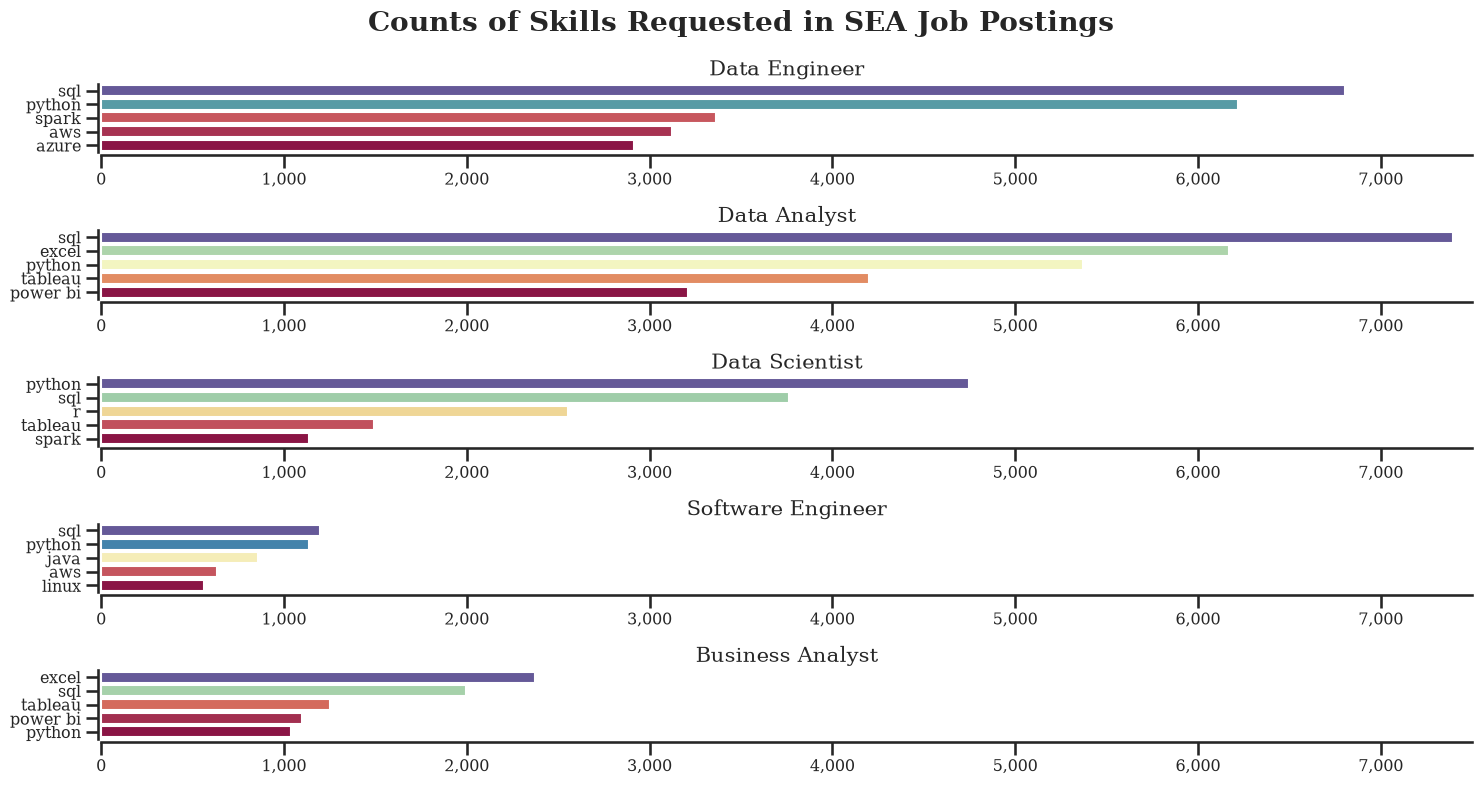

In [66]:
fig, ax = plt.subplots(
                        len(top5_job_title)
                        , 1
                        , figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'Spectral'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

for index, job in enumerate(top5_job_title):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job].head()[::-1]
    sns.barplot(
                data = df_plot
                , x = 'skill_count'
                , y = 'job_skills'
                , ax = ax[index]
                , hue = 'skill_count'
                , palette = 'Spectral'
                , legend = False)

    ax[index].set_title(
                        job
                        , fontsize = 15
                        , loc = 'center')

    ax[index].invert_yaxis()
    ax[index].set_ylabel('')
    ax[index].set_xlabel('')
    ax[index].set_xlim(0, 7500) # make the scales the same
    ax[index].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

sns.despine(offset=2)
fig.suptitle(
            'Counts of Skills Requested in SEA Job Postings'
            , fontsize=20
            , fontweight = 'bold')

fig.tight_layout(h_pad=1) # fix the overlap
plt.show()

In [11]:
df_plot

,job_skills,job_title_short,skill_count
736,linux,Software Engineer,560
110,aws,Software Engineer,632
618,java,Software Engineer,858
1108,python,Software Engineer,1135
1400,sql,Software Engineer,1199
